<a href="https://colab.research.google.com/github/tungtran0911/vol-har-conformal/blob/main/notebooks/A2_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Real dataset: SPY (the ETF that tracks the S&P 500) daily prices from Yahoo Finance, 2005-01 to 2026-08
- Task: at the close of trading day $t$, forecast tomorrow's variance $v_{t+1}$, i.e. how much the price is likely to move
  tomorrow. Risk managers use this number to size positions and set Value-at-Risk limits.
- Input variables: today's variance $v_t$, the mean variance of the last 5 days and of the last 22 days
  (all computed from the last 22 days of open / high / low / close prices)
- Output: one positive number $\hat y_{t+1}$, a daily variance in %$^2$ ($\sqrt{252\,\hat y}$ is the annualised volatility in %)
- Target variable: true variance cannot be observed, so $v_t$ = (overnight gap)$^2$ + Garman–Klass range estimator

Implementations of Linear Regression for this study:
1. Simple Linear Regression - 1 input (today's variance), 1 output
2. Multiple Linear Regression (the HAR model) - 3 inputs (daily, weekly, monthly variance), 1 output
3. HAR with the QLIKE loss - log link, trained by gradient descent (compared with the same model fitted by OLS
   on $\ln y$, with and without the Jensen correction)
4. HAR with the QLIKE loss and hyperparameter tuning of the training-window length W by grid search

Important to note that all models use the same chronological split: train = targets up to 2016,
validation = 2017–2019, test = 2020-01 to 2026-08. The data are never shuffled, because each day depends on the days
before it and shuffling would train on the future. Models 1–3 are compared on validation; the test years are used
once, in Final Findings, against two baselines (naive "tomorrow = today" and GARCH(1,1)). The models differ by input
variables, loss function and optimisation algorithm, one change at a time, so the effect of each change can be measured.

# Data Preparation

Data source - SPY daily open / high / low / close (fixed copy stored in the project repository)

Variance proxy - overnight gap$^2$ + Garman–Klass (1980): $v_t = (\ln O_t - \ln C_{t-1})^2 + \tfrac12(\ln H_t - \ln L_t)^2 - (2\ln 2 - 1)(\ln C_t - \ln O_t)^2$

Loss functions - MSE $=\frac1n\sum(y-\hat y)^2$ and QLIKE $=\frac1n\sum\left(\frac{y}{\hat y} - \ln\frac{y}{\hat y} - 1\right)$

daily variance: median 0.50, maximum 153 on 2020-03-16 | daily volatility: 10% of days below 0.35%, maximum 12.4%
5449 trading days -> 5426 samples: train 2998, validation 754, test 1674
Naive forecast on validation: MSE 0.981, QLIKE 0.7091


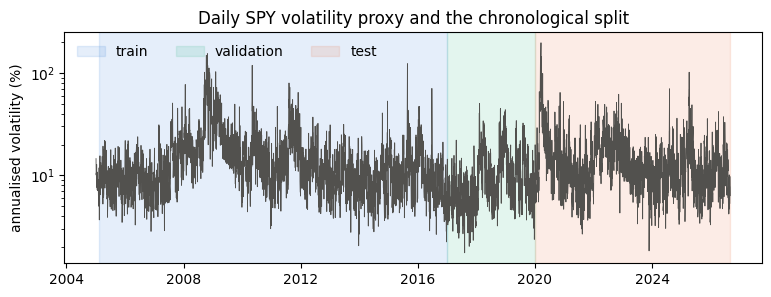

In [1]:
# STEP 1 IMPORTING NECESSARY LIBRARIES

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.makedirs("figures", exist_ok=True)  # every plot is also saved as a PNG for the report
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

# STEP 2 LOADS SPY DAILY PRICES

# Yahoo Finance, adjusted for splits and dividends, 2005-01-03 to 2026-08-31.
# A fixed copy lives in the project repository, so every run uses identical data.
URL = "https://raw.githubusercontent.com/tungtran0911/vol-har-conformal/main/data/spy_ohlc.csv"
LOCAL = "data/spy_ohlc.csv"  # the same file, when the project folder is available
prices = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL, index_col="date", parse_dates=True)

# drop missing or non-positive rows, and make sure low <= open, close <= high
prices = prices.dropna()
prices = prices[(prices > 0).all(axis=1)]
prices["high"] = prices[["open", "high", "close"]].max(axis=1)
prices["low"] = prices[["open", "low", "close"]].min(axis=1)

# STEP 3 DAILY VARIANCE (the quantity we forecast)

o, h, l, c = (np.log(prices[k]) for k in ["open", "high", "low", "close"])
overnight = (o - c.shift(1)) ** 2  # yesterday's close -> today's open
intraday = 0.5 * (h - l) ** 2 - (2 * np.log(2) - 1) * (c - o) ** 2  # Garman-Klass, uses the day's high-low range
v = 1e4 * (overnight + intraday).dropna().clip(lower=1e-8)  # daily variance in %^2 (1.0 = a 1% daily move)
returns = 100 * (c - c.shift(1)).reindex(v.index)  # daily log return in %, used by the GARCH baseline
print(f"daily variance: median {v.median():.2f}, maximum {v.max():.0f} on {v.idxmax().date()} | daily volatility: "
      f"10% of days below {np.sqrt(v.quantile(0.1)):.2f}%, maximum {np.sqrt(v.max()):.1f}%")

# STEP 4 INPUT VARIABLES AND TARGET

data = pd.DataFrame({
    "v_d": v,                     # today's variance
    "v_w": v.rolling(5).mean(),   # mean of the last 5 days (one week)
    "v_m": v.rolling(22).mean(),  # mean of the last 22 days (one month)
    "y": v.shift(-1),             # target: tomorrow's variance
    "target_date": v.index.to_series().shift(-1),
}).dropna()

# STEP 5 SPLIT DATA BY DATE (never shuffled)

# split on the date of the TARGET, so no training target falls inside the validation or test years
train = data[data["target_date"] <= "2016-12-31"]
val = data[(data["target_date"] > "2016-12-31") & (data["target_date"] <= "2019-12-31")]
test = data[data["target_date"] > "2019-12-31"]
print(f"{len(prices)} trading days -> {len(data)} samples: train {len(train)}, validation {len(val)}, test {len(test)}")

# STEP 6 DEFINE LOSS FUNCTIONS (MSE and QLIKE)

def calculate_mse(y_true, y_pred):
    # average squared error: a few very volatile days dominate it
    return np.mean((y_true - y_pred) ** 2)


def calculate_qlike(y_true, y_pred):
    # Log-combined relative ratio y/y_pred - log(y/y_pred) - 1
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)


# reference before any learning ("naive"): tomorrow's variance = today's
scores = {"Naive (tomorrow = today)": {"val MSE": calculate_mse(val["y"], val["v_d"]),
                                       "val QLIKE": calculate_qlike(val["y"], val["v_d"])}}
print(f"Naive forecast on validation: MSE {scores['Naive (tomorrow = today)']['val MSE']:.3f}, "
      f"QLIKE {scores['Naive (tomorrow = today)']['val QLIKE']:.4f}")

# STEP 7 PLOT THE TARGET

plt.figure(figsize=(9, 3))
plt.plot(v.index, np.sqrt(252 * v), color=GREY, linewidth=0.6)
for part, color, name in ((train, BLUE, "train"), (val, AQUA, "validation"), (test, ORANGE, "test")):
    plt.axvspan(part["target_date"].iloc[0], part["target_date"].iloc[-1], color=color, alpha=0.12, label=name)
plt.yscale("log")
plt.ylabel("annualised volatility (%)")
plt.title("Daily SPY volatility proxy and the chronological split")
plt.legend(frameon=False, ncol=3)
plt.savefig("figures/step0_data.png", dpi=200, bbox_inches="tight")
plt.show()

# Simple Linear Regression

Input Variable - today's variance $v_t$

Hypothesis - $\hat y_{t+1} = b_0 + b_1 v_t$

Loss Function - Mean Squared Error (MSE)

Optimisation Algorithm - Ordinary Least Squares (OLS): solve the normal equations $(X^\top X)\,b = X^\top y$

Validation MSE: 0.915 | Validation QLIKE: 0.6684


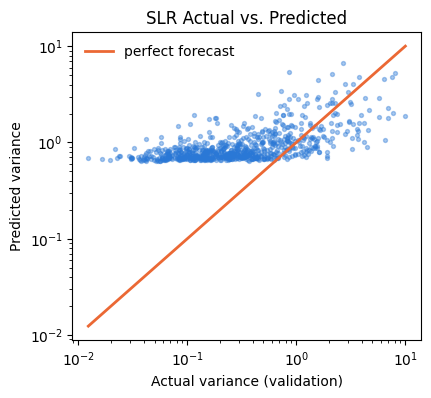

Intercept (b0): 0.6345
Slope (b1): 0.5969 -> 60% of today's variance carries into tomorrow; the rest reverts to the long-run level b0 / (1 - b1) = 1.57 (annualised volatility 20%)


In [3]:
# STEP 1 SELECT THE INPUT VARIABLE

X_train, y_train = train[["v_d"]].to_numpy(), train["y"].to_numpy()
X_val, y_val = val[["v_d"]].to_numpy(), val["y"].to_numpy()

# STEP 2 ADDS COLUMN OF ONES

# the column of ones carries the intercept b0 (the forecast when today's variance is 0)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]

# STEP 3 IMPLEMENT LINEAR REGRESSION WITH OLS

def ols(X, y):
    # b = (X^T X)^(-1) X^T y; solve() gives the same b without forming the inverse (numerically safer)
    return np.linalg.solve(X.T @ X, X.T @ y)

# STEP 4 TRAINS SLR MODEL

coefficients = ols(X_train, y_train)

# Make predictions on the validation set
y_val_pred = X_val @ coefficients  # represents the hypothesis function

# STEP 5 EVALUATION

scores["1. Simple LR"] = {"val MSE": calculate_mse(y_val, y_val_pred), "val QLIKE": calculate_qlike(y_val, y_val_pred)}
print(f"Validation MSE: {scores['1. Simple LR']['val MSE']:.3f} | Validation QLIKE: {scores['1. Simple LR']['val QLIKE']:.4f}")

plt.figure(figsize=(4.5, 4))
plt.scatter(y_val, y_val_pred, s=8, alpha=0.4, color=BLUE)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color=ORANGE, linewidth=2, label="perfect forecast")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual variance (validation)")
plt.ylabel("Predicted variance")
plt.title("SLR Actual vs. Predicted")
plt.legend(frameon=False)
plt.savefig("figures/step1_simple_lr.png", dpi=200, bbox_inches="tight")
plt.show()

intercept, slope = coefficients
print(f"Intercept (b0): {intercept:.4f}")
print(f"Slope (b1): {slope:.4f} -> {slope:.0%} of today's variance carries into tomorrow; the rest reverts to the "
      f"long-run level b0 / (1 - b1) = {intercept / (1 - slope):.2f} (annualised volatility "
      f"{np.sqrt(252 * intercept / (1 - slope)):.0f}%)")

# Multiple Linear Regression (HAR)

Input Variables - today's variance $v_t$, the 5-day mean $\bar v^{(5)}_t$ and the 22-day mean $\bar v^{(22)}_t$
(the HAR model of Corsi, 2009: traders with daily, weekly and monthly horizons each react to a different average)

Hypothesis - $\hat y_{t+1} = b_0 + b_d v_t + b_w \bar v^{(5)}_t + b_m \bar v^{(22)}_t$

Loss Function - Mean Squared Error (MSE)

Optimisation Algorithm - Ordinary Least Squares (OLS)

Validation MSE: 0.719 | Validation QLIKE: 0.4224


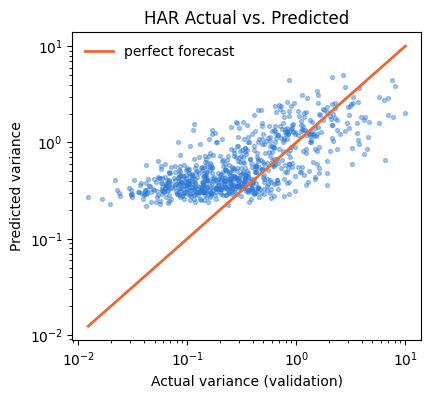

Coefficients [b0, b_d, b_w, b_m]: [0.1724 0.2962 0.2472 0.3471]
Persistence b_d + b_w + b_m = 0.890 (simple LR: 0.597)


In [4]:
# STEP 1 SELECT THE INPUT VARIABLES

har_inputs = ["v_d", "v_w", "v_m"]
X_train, y_train = train[har_inputs].to_numpy(), train["y"].to_numpy()
X_val, y_val = val[har_inputs].to_numpy(), val["y"].to_numpy()

# STEP 2 ADDS COLUMN OF ONES

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]

# STEP 3 TRAINS THE MODEL WITH OLS (same function as above, now 4 columns)

coefficients = ols(X_train, y_train)

# Make predictions on the validation set
y_val_pred = X_val @ coefficients  # hypothesis function

# STEP 4 EVALUATION

scores["2. HAR (OLS)"] = {"val MSE": calculate_mse(y_val, y_val_pred), "val QLIKE": calculate_qlike(y_val, y_val_pred)}
print(f"Validation MSE: {scores['2. HAR (OLS)']['val MSE']:.3f} | Validation QLIKE: {scores['2. HAR (OLS)']['val QLIKE']:.4f}")

plt.figure(figsize=(4.5, 4))
plt.scatter(y_val, y_val_pred, s=8, alpha=0.4, color=BLUE)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color=ORANGE, linewidth=2, label="perfect forecast")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual variance (validation)")
plt.ylabel("Predicted variance")
plt.title("HAR Actual vs. Predicted")
plt.legend(frameon=False)
plt.savefig("figures/step2_har.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Coefficients [b0, b_d, b_w, b_m]: {np.round(coefficients, 4)}")
print(f"Persistence b_d + b_w + b_m = {coefficients[1:].sum():.3f} (simple LR: {slope:.3f})")

# HAR + QLIKE Loss

Input Variables - the logs of the same three HAR inputs, standardised (mean 0, sd 1 on the training set)

Hypothesis - $\hat y_{t+1} = \exp(b_0 + b_d \ln v_t + b_w \ln \bar v^{(5)}_t + b_m \ln \bar v^{(22)}_t)$
(log link: the forecast is always positive, which QLIKE needs)

Loss Function - QLIKE. MSE is dominated by a few crash days; QLIKE depends only on the ratio $y/\hat y$
and punishes under-predicting risk more than over-predicting it

Optimisation Algorithm - gradient descent, $b \leftarrow b - \eta\,\nabla$, with
$\nabla = \frac1n X^\top (1 - y/\hat y)$ (no closed form any more; the loss is convex in $b$, so gradient descent
reaches the global minimum)

Comparison - the same log model fitted in closed form by OLS on $\ln y$, with and without the Jensen correction
(STEP 6), to show what the QLIKE loss adds

QLIKE(actual 2, predicted 1) = 0.307   (under-predicted risk)
QLIKE(actual 1, predicted 2) = 0.193   (over-predicted risk)
learning rate 0.1: 1509 iterations, loss fell at every step: True
learning rate 0.3: 500 iterations, loss fell at every step: True
learning rate 0.5: 299 iterations, loss fell at every step: True
Gradient descent stopped after 500 iterations, training QLIKE 0.3669
Validation MSE: 0.705 | Validation QLIKE: 0.3758


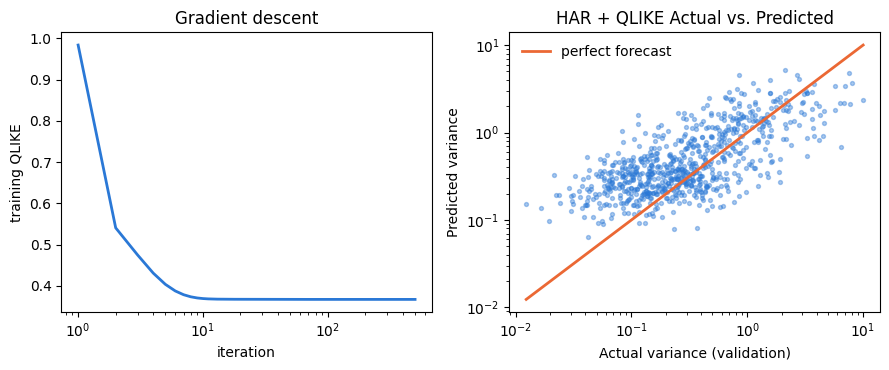

Coefficients [b_d, b_w, b_m] on the log inputs: [0.2513 0.4093 0.2531]
3a. HAR log-OLS: validation QLIKE 0.4249, mean actual/predicted 1.35
3b. HAR log-OLS + Jensen: validation QLIKE 0.3768, mean actual/predicted 0.96
3. HAR + QLIKE: validation QLIKE 0.3758, mean actual/predicted 0.94 (on train 1.0000: at the minimum of QLIKE it is exactly 1, no assumption)


,val MSE,val QLIKE
Naive (tomorrow = today),0.9809,0.7091
1. Simple LR,0.9150,0.6684
2. HAR (OLS),0.7191,0.4224
3. HAR + QLIKE,0.7052,0.3758
3a. HAR log-OLS,0.7692,0.4249
3b. HAR log-OLS + Jensen,0.7108,0.3768


In [5]:
# STEP 1 WHY QLIKE: under- vs over-prediction by 2x

print(f"QLIKE(actual 2, predicted 1) = {calculate_qlike(2.0, 1.0):.3f}   (under-predicted risk)")
print(f"QLIKE(actual 1, predicted 2) = {calculate_qlike(1.0, 2.0):.3f}   (over-predicted risk)")

# STEP 2 LOG INPUTS, STANDARDISE, ADD COLUMN OF ONES

F_train, y_train = np.log(train[har_inputs].to_numpy()), train["y"].to_numpy()
F_val, y_val = np.log(val[har_inputs].to_numpy()), val["y"].to_numpy()
mean, std = F_train.mean(axis=0), F_train.std(axis=0)  # from the training set only
X_train = np.c_[np.ones(len(F_train)), (F_train - mean) / std]
X_val = np.c_[np.ones(len(F_val)), (F_val - mean) / std]

# STEP 3 IMPLEMENT GRADIENT DESCENT ON QLIKE

def gradient_descent(X, y, b, learning_rate=0.3, tol=1e-8, max_iter=20000):
    # learning rate 0.3: the loss falls at every step
    losses = []
    for _ in range(max_iter):
        y_pred = np.exp(X @ b)                    # hypothesis function
        ratio = y / y_pred
        losses.append(np.mean(ratio - np.log(ratio) - 1))  # QLIKE
        gradient = X.T @ (1 - ratio) / len(y)     # derivative of QLIKE with respect to b
        if np.abs(gradient).max() < tol:          # stop when the slope is flat
            break
        b = b - learning_rate * gradient
    return b, losses

# STEP 4 TRAINS THE MODEL

b_start = np.array([np.log(y_train.mean()), 0.0, 0.0, 0.0])  # start: constant forecast = average variance
for rate in (0.1, 0.3, 0.5):  # choosing the learning rate: all three reach the same minimum, 0.3 is 3x faster than 0.1
    _, path = gradient_descent(X_train, y_train, b_start, learning_rate=rate)
    print(f"learning rate {rate}: {len(path) - 1} iterations, loss fell at every step: {bool(np.all(np.diff(path) <= 1e-12))}")
b, losses = gradient_descent(X_train, y_train, b_start)
print(f"Gradient descent stopped after {len(losses) - 1} iterations, training QLIKE {losses[-1]:.4f}")

# Make predictions on the validation set
y_val_pred = np.exp(X_val @ b)

# STEP 5 EVALUATION

scores["3. HAR + QLIKE"] = {"val MSE": calculate_mse(y_val, y_val_pred), "val QLIKE": calculate_qlike(y_val, y_val_pred)}
print(f"Validation MSE: {scores['3. HAR + QLIKE']['val MSE']:.3f} | Validation QLIKE: {scores['3. HAR + QLIKE']['val QLIKE']:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))
ax1.plot(range(1, len(losses) + 1), losses, color=BLUE, linewidth=2)
ax1.set(xscale="log", xlabel="iteration", ylabel="training QLIKE", title="Gradient descent")
ax2.scatter(y_val, y_val_pred, s=8, alpha=0.4, color=BLUE)
ax2.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color=ORANGE, linewidth=2, label="perfect forecast")
ax2.set(xscale="log", yscale="log", xlabel="Actual variance (validation)", ylabel="Predicted variance",
        title="HAR + QLIKE Actual vs. Predicted")
ax2.legend(frameon=False)
fig.tight_layout()
plt.savefig("figures/step3_har_qlike.png", dpi=200, bbox_inches="tight")
plt.show()

slopes = b[1:] / std  # undo the standardisation: coefficients on ln v_d, ln v_w, ln v_m
print(f"Coefficients [b_d, b_w, b_m] on the log inputs: {np.round(slopes, 4)}")

# STEP 6 COMPARE: THE SAME LOG MODEL FITTED BY OLS ON ln(y)

# closed form, no gradient descent: regress ln(y) on the same inputs
b_log = ols(X_train, np.log(y_train))
residual_var = np.var(np.log(y_train) - X_train @ b_log, ddof=X_train.shape[1])
# exp(average of ln y) is the median of y, which is below its mean -> forecasts too low.
# Jensen correction: multiply by exp(s^2 / 2); exact only if the log errors are normally distributed.
for name, pred in (("3a. HAR log-OLS", np.exp(X_val @ b_log)),
                   ("3b. HAR log-OLS + Jensen", np.exp(X_val @ b_log + residual_var / 2))):
    scores[name] = {"val MSE": calculate_mse(y_val, pred), "val QLIKE": calculate_qlike(y_val, pred)}
    print(f"{name}: validation QLIKE {scores[name]['val QLIKE']:.4f}, mean actual/predicted {np.mean(y_val / pred):.2f}")
print(f"3. HAR + QLIKE: validation QLIKE {scores['3. HAR + QLIKE']['val QLIKE']:.4f}, "
      f"mean actual/predicted {np.mean(y_val / y_val_pred):.2f} "
      f"(on train {np.mean(y_train / np.exp(X_train @ b)):.4f}: at the minimum of QLIKE it is exactly 1, no assumption)")

pd.DataFrame(scores).T.round(4)

## Incl. Hyperparameter Tuning

Hyperparameter - the training-window length $W$. In deployment the model is re-trained every evening on the last
$W$ days only, because the way volatility behaves drifts over the years: a large $W$ gives stable coefficients, a
small $W$ adapts faster.

Grid search - $W \in \{250, 500, 1000, 2000\}$ days, scored on the validation years only: for every day of
2017–2019, train on the $W$ days before it and forecast that day.

W =  250 days (~1.0 years): validation QLIKE 0.3926
W =  500 days (~2.0 years): validation QLIKE 0.3892
W = 1000 days (~4.0 years): validation QLIKE 0.3795
W = 2000 days (~7.9 years): validation QLIKE 0.3757
Best W: 2000


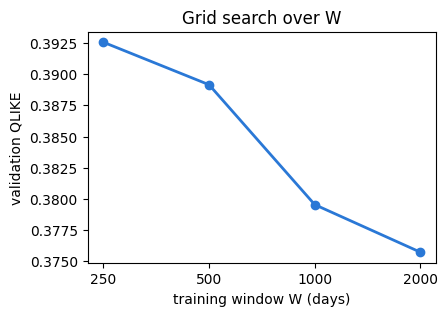

In [6]:
# STEP 1 ROLLING FORECAST (train on the last W days, forecast the next day)

V, Y = data[har_inputs].to_numpy(), data["y"].to_numpy()
dates = data["target_date"]


def forecast_rows(start, end, W):
    # rows whose target date is in [start, end] and that have W earlier rows to train on
    rows = np.flatnonzero((dates >= start) & (dates <= end))
    return rows[rows >= W]


def rolling_har_qlike(start, end, W):
    predictions, b = [], None
    for i in forecast_rows(start, end, W):
        F, y = np.log(V[i - W:i]), Y[i - W:i]  # only the W days before day i: no look-ahead
        mean, std = F.mean(axis=0), F.std(axis=0)
        X = np.c_[np.ones(W), (F - mean) / std]
        if b is None:
            b = np.array([np.log(y.mean()), 0.0, 0.0, 0.0])
        b, _ = gradient_descent(X, y, b)  # warm start from yesterday's solution
        x_today = np.r_[1.0, (np.log(V[i]) - mean) / std]
        predictions.append(np.exp(x_today @ b))
    return np.array(predictions)

# STEP 2 GRID SEARCH OVER W ON VALIDATION

windows = [250, 500, 1000, 2000]
val_qlike = {}
for W in windows:
    rows = forecast_rows("2017-01-01", "2019-12-31", W)
    val_qlike[W] = calculate_qlike(Y[rows], rolling_har_qlike("2017-01-01", "2019-12-31", W))
    print(f"W = {W:>4} days (~{W / 252:.1f} years): validation QLIKE {val_qlike[W]:.4f}")

best_W = min(val_qlike, key=val_qlike.get)
print(f"Best W: {best_W}")

plt.figure(figsize=(4.5, 3))
plt.plot(windows, list(val_qlike.values()), marker="o", color=BLUE, linewidth=2)
plt.xscale("log")
plt.xticks(windows, [str(w) for w in windows])
plt.minorticks_off()
plt.xlabel("training window W (days)")
plt.ylabel("validation QLIKE")
plt.title("Grid search over W")
plt.savefig("figures/step4_tuning.png", dpi=200, bbox_inches="tight")
plt.show()

# Final Findings

Test period 2020-01 to 2026-08 (includes the COVID crash of March 2020), used once. Every model is re-trained each
day on the last $W$ days (the best $W$ from the grid search) and forecasts the next day.

Baselines - naive (tomorrow = today, no learning) and GARCH(1,1) (Bollerslev, 1986), the standard volatility model
in finance: $h_{t+1} = \omega + \alpha r_t^2 + \beta h_t$, fitted by maximum likelihood on daily returns every 5 days

Test: 1674 days, 2020-01-02 to 2026-08-31, W = 2000
                          test QLIKE  test MSE  mean actual/predicted
Naive (tomorrow = today)      0.8205   28.6021                 1.8206
1. Simple LR                  0.5270   29.3997                 0.9917
2. HAR (OLS)                  0.4483   28.3119                 0.9933
3. HAR + QLIKE                0.4329   21.2230                 1.0474
3a. HAR log-OLS               0.5525   25.0955                 1.5825
3b. HAR log-OLS + Jensen      0.4327   22.3019                 1.0785
Baseline: GARCH(1,1)          0.4627   19.1973                 1.0886
2. HAR (OLS)             10 worst days = 86% of test MSE; test MSE without March 2020 = 4.75
3. HAR + QLIKE           10 worst days = 84% of test MSE; test MSE without March 2020 = 4.53
Baseline: GARCH(1,1)     10 worst days = 79% of test MSE; test MSE without March 2020 = 4.58


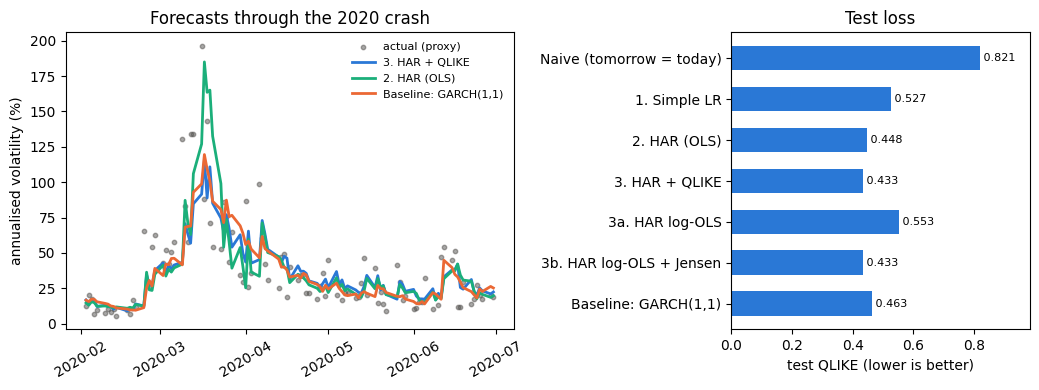

In [7]:
from scipy.optimize import minimize
from scipy.signal import lfilter

# STEP 1 ROLLING FORECASTS FOR THE LINEAR MODELS

START, END = "2017-01-01", "2026-12-31"  # forecast every day from 2017; the test years are reported below
rows = forecast_rows(START, END, best_W)
forecasts = pd.DataFrame({"y": Y[rows]}, index=pd.DatetimeIndex(dates.iloc[rows], name="target_date"))


def rolling_ols(columns):
    X_all = np.c_[np.ones(len(data)), data[columns].to_numpy()]
    return np.array([X_all[i] @ ols(X_all[i - best_W:i], Y[i - best_W:i]) for i in rows])


def rolling_log_ols(jensen):
    X_all = np.c_[np.ones(len(data)), np.log(V)]
    predictions = []
    for i in rows:
        X, log_y = X_all[i - best_W:i], np.log(Y[i - best_W:i])
        b_log = ols(X, log_y)
        s2 = np.var(log_y - X @ b_log, ddof=X.shape[1]) if jensen else 0.0
        predictions.append(np.exp(X_all[i] @ b_log + s2 / 2))
    return np.array(predictions)


forecasts["naive"] = V[rows, 0]
forecasts["slr"] = rolling_ols(["v_d"])
forecasts["har_ols"] = rolling_ols(har_inputs)
forecasts["har_qlike"] = rolling_har_qlike(START, END, best_W)
forecasts["har_log_ols"] = rolling_log_ols(jensen=False)
forecasts["har_log_ols_jensen"] = rolling_log_ols(jensen=True)

# STEP 2 BASELINE: GARCH(1,1)

def garch_variance(params, r2, h0):
    # h[t+1] = omega + alpha * r2[t] + beta * h[t], starting from h0 (lfilter runs this loop in compiled code)
    omega, alpha, beta = params
    return np.r_[h0, lfilter([1.0], [1.0, -beta], omega + alpha * r2, zi=[beta * h0])[0]]


def garch_neg_loglik(params, r2, h0):
    h = garch_variance(params, r2, h0)[:-1]
    return 1e12 if np.any(h <= 0) else 0.5 * np.sum(np.log(h) + r2 / h)  # Gaussian, without constants


def fit_garch(r2, x0):
    h0 = r2.mean()
    x0 = (0.05 * h0, 0.08, 0.90) if x0 is None else x0
    result = minimize(garch_neg_loglik, x0, args=(r2, h0), method="SLSQP",
                      bounds=[(1e-8, None), (1e-8, 1.0), (0.0, 1.0)],
                      constraints=[{"type": "ineq", "fun": lambda p: 0.9999 - p[1] - p[2]}],  # alpha + beta < 1
                      options={"maxiter": 200, "ftol": 1e-10})
    return result.x


position = v.index.get_indexer(data.index)  # where each feature date sits in the return series
garch, params = [], None
for k, i in enumerate(rows):
    r2 = returns.to_numpy()[position[i] - best_W + 1: position[i] + 1] ** 2  # the last W daily returns
    if params is None or k % 5 == 0:
        params = fit_garch(r2, params)  # re-fit every 5 days, warm start
    garch.append(garch_variance(params, r2, r2.mean())[-1])
forecasts["garch"] = garch

# STEP 3 EVALUATION ON THE TEST YEARS

test_fc = forecasts[forecasts.index > "2019-12-31"]
names = {"naive": "Naive (tomorrow = today)", "slr": "1. Simple LR", "har_ols": "2. HAR (OLS)",
         "har_qlike": "3. HAR + QLIKE", "har_log_ols": "3a. HAR log-OLS", "har_log_ols_jensen": "3b. HAR log-OLS + Jensen",
         "garch": "Baseline: GARCH(1,1)"}
results = pd.DataFrame({names[m]: {"test QLIKE": calculate_qlike(test_fc["y"], test_fc[m]),
                                   "test MSE": calculate_mse(test_fc["y"], test_fc[m]),
                                   "mean actual/predicted": np.mean(test_fc["y"] / test_fc[m])}  # 1 = right level
                        for m in names}).T
print(f"Test: {len(test_fc)} days, {test_fc.index[0].date()} to {test_fc.index[-1].date()}, W = {best_W}")
print(results.round(4).to_string())

# how much of each model's test MSE comes from its 10 worst days (all in March 2020)?
march_2020 = (test_fc.index >= "2020-03-01") & (test_fc.index <= "2020-03-31")
for m in ["har_ols", "har_qlike", "garch"]:
    squared_errors = (test_fc["y"] - test_fc[m]) ** 2
    print(f"{names[m]:<24} 10 worst days = {squared_errors.nlargest(10).sum() / squared_errors.sum():.0%} of test MSE; "
          f"test MSE without March 2020 = {squared_errors[~march_2020].mean():.2f}")

# STEP 4 PLOTS

crash = test_fc.loc["2020-02-01":"2020-06-30"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4), gridspec_kw={"width_ratios": [1.5, 1]})
ax1.scatter(crash.index, np.sqrt(252 * crash["y"]), s=10, color=GREY, alpha=0.5, label="actual (proxy)")
for m, color in (("har_qlike", BLUE), ("har_ols", AQUA), ("garch", ORANGE)):
    ax1.plot(crash.index, np.sqrt(252 * crash[m]), color=color, linewidth=2, label=names[m])
ax1.set(ylabel="annualised volatility (%)", title="Forecasts through the 2020 crash")
ax1.tick_params(axis="x", labelrotation=30)
ax1.legend(frameon=False, fontsize=8)
order = list(names.values())[::-1]
ax2.barh(order, results.loc[order, "test QLIKE"], color=BLUE, height=0.6)
for k, value in enumerate(results.loc[order, "test QLIKE"]):
    ax2.text(value, k, f" {value:.3f}", va="center", fontsize=8)
ax2.set(xlabel="test QLIKE (lower is better)", title="Test loss", xlim=(0, results["test QLIKE"].max() * 1.2))
fig.tight_layout()
plt.savefig("figures/step5_test.png", dpi=200, bbox_inches="tight")
plt.show()

Test QLIKE scores (lower is better):
- Naive (tomorrow = today) = 0.821
- SLR = 0.527
- HAR = 0.448
- HAR + QLIKE (W = 2000) = 0.433
- HAR log-OLS = 0.553 (same log model fitted by OLS on ln y), HAR log-OLS + Jensen = 0.433
- GARCH(1,1) baseline = 0.463

As such, each step improves the forecast, on validation and on test. Most of the gain comes from learning a
regression instead of copying today (SLR) and from adding the weekly and monthly averages (HAR). Training on QLIKE
adds a smaller gain, and HAR + QLIKE beats the standard GARCH model on QLIKE.

What QLIKE adds is the right level, not a better shape. The same log model fitted by OLS on $\ln y$ forecasts the
median, not the mean: on test the actual variance is on average 1.58 times its forecast, so risk is under-predicted,
and its QLIKE is the worst of the HAR models (0.553). The Jensen correction repairs the level (0.433), but only by
assuming normally distributed log errors. QLIKE training gets the level right by construction (actual/predicted = 1 on
the training data, with no assumption). On SPY the assumption holds well enough that the two tie (0.4327 vs 0.4329),
so the claim is not that QLIKE beats every fit, but that it needs no distributional assumption and trains on the
criterion the model is judged by.

The loss function decides the winner. On MSE, GARCH is best (19.20 vs 21.22) because the 10 worst days, all in
March 2020, make up 79–86% of every model's test MSE; without March 2020 the three MSEs are within 5% of each other
and HAR + QLIKE is lowest. The model trained on MSE (HAR OLS) even has the worst test MSE of the three: it over-reacts
to single extreme days (forecast of 185% annualised volatility on 2020-03-17).

Limitations: the target is a noisy proxy of true variance, one asset only, a linear model with 3 inputs, a one-day
horizon, and no formal significance test of the differences.